# Hybrid Nuclei Image-Analysis Pipeline (Google Colab version)

Raw image -> segmentation -> quantitative region features -> structured JSON record -> short narrative.

Modality: nuclei microscopy (`nuclei_dataset.zip`, https://github.com/Nickolay-K/Assingnment-3-dataset).
Local models via Ollama, running inside this Colab VM: **llama3.2-vision** (Task 1) and **phi3** (Task 2/4).

This follows the same Colab setup pattern used in this module's labs: install Ollama inside the VM,
start it as a background server, pull the models, then everything else runs exactly like a local
Ollama setup would.

## Important Note Before You Start

The outputs generated in this notebook are **for educational use only**. None of the models used here
have been validated for clinical use, and vision-language / text models can produce confident,
plausible-sounding output that is wrong. This is discussed directly in the report (Question 4/5).

## Google Colab Setup

### Before you run anything

1. **Set the runtime to GPU**: *Runtime -> Change runtime type -> T4 GPU -> Save*
2. **Run the four setup cells below in order** before any other cell.
3. Model downloads can take **5-15 minutes** on a fresh session — this is normal, not a hang.

> **Session note**: Colab sessions reset after a period of inactivity or when you disconnect. If you
> reconnect to a new session, re-run **all** setup cells (including the dataset download further down)
> before continuing — nothing in `/content/` persists between sessions, including Ollama itself and any
> downloaded models.

### Why the Ollama version is pinned

`ollama pull llama3.2-vision` currently fails on the newest Ollama releases (v0.30 and later) with
`error loading model: unknown model architecture: 'mllama'` — a confirmed, unresolved regression in
Ollama's newer inference engine (see
[ollama/ollama#16490](https://github.com/ollama/ollama/issues/16490) and
[#16547](https://github.com/ollama/ollama/issues/16547)). The install cell below pins Ollama to
**v0.24.0**, a version confirmed to still support `llama3.2-vision` correctly, to avoid hitting this bug
inside Colab as well.

### Models used

| Model | Purpose | Approx. size |
|---|---|---|
| `llama3.2-vision` | Task 1: direct image description (VLM) | ~7.9 GB |
| `phi3` | Task 2 / Task 4: numbers-first description (text LLM) | ~2.2 GB |

Both fit comfortably within Colab's disk and the free T4's 15 GB VRAM.

In [4]:
# Step 1: Verify GPU
import subprocess

result = subprocess.run(
    ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
    capture_output=True, text=True
)
if result.returncode == 0:
    print('GPU detected:', result.stdout.strip())
else:
    print('No GPU found.')
    print('   Go to Runtime -> Change runtime type -> T4 GPU, then reconnect.')
    print('   The notebook will still run on CPU but inference will be much slower.')

GPU detected: Tesla T4, 15360 MiB


In [5]:
#  Step 2: Install Python packages and Ollama (pinned to a known-good version)
!pip install -q ollama scikit-image scikit-learn matplotlib pandas pillow requests tqdm scipy

# zstd is required to extract this Ollama release's archive; Colab's base image doesn't
# always have it preinstalled.
!apt-get install -y zstd -qq

# Pinned to 0.24.0 -- see the markdown note above for why. Do NOT drop the OLLAMA_VERSION
# pin unless you've separately confirmed a newer release has fixed the mllama/vision bug.
!curl -fsSL https://ollama.com/install.sh | OLLAMA_VERSION=0.24.0 sh

Selecting previously unselected package zstd.
(Reading database ... 122492 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [6]:
# Step 3: Start the Ollama server
import subprocess, time, urllib.request

server = subprocess.Popen(
    ['ollama', 'serve'],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)

for attempt in range(30):
    try:
        urllib.request.urlopen('http://localhost:11434', timeout=1)
        print(f'Ollama server ready (after {attempt + 1}s)')
        break
    except Exception:
        time.sleep(1)
else:
    print('Ollama did not start in 30s. Try re-running this cell.')

Ollama server ready (after 2s)


In [7]:
# Step 4: Pull the models used in this pipeline
# Total download: ~10 GB. One-time cost per Colab session (re-run if the session resets).

print('Pulling phi3 (~2.2 GB) ...')
!ollama pull phi3

print()
print('Pulling llama3.2-vision (~7.9 GB) ...')
!ollama pull llama3.2-vision

print()
print('Verifying version (should NOT be affected by the mllama bug on 0.24.0):')
!ollama --version

print()
print('All models downloaded and ready.')

Pulling phi3 (~2.2 GB) ...


Pulling llama3.2-vision (~7.9 GB) ...


Verifying version (should NOT be affected by the mllama bug on 0.24.0):
ollama version is 0.24.0

All models downloaded and ready.


## Setup: imports, folders, and configuration

In [8]:
import os, sys, json, zipfile, random, time, re, base64

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from IPython.display import Image as IPImage, display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from skimage import measure, morphology
from skimage.filters import threshold_otsu
from scipy.ndimage import gaussian_filter

import ollama

In [9]:
# Folders: everything lives under /content/, Colab's ephemeral working directory.
# We use absolute paths (matching the pattern from the earlier labs) so every cell below
# resolves the same location regardless of where/how the notebook was opened.
BASE_DIR = "/content/nuclei_pipeline"
DATA_DIR = os.path.join(BASE_DIR, "data")
RAW_DIR = os.path.join(DATA_DIR, "raw")
PROC_DIR = os.path.join(DATA_DIR, "processed")
PROC_IMG_DIR = os.path.join(PROC_DIR, "images")
PROC_MASK_DIR = os.path.join(PROC_DIR, "masks")
SPLIT_FILE = os.path.join(PROC_DIR, "split.json")

OUT_DIR = os.path.join(BASE_DIR, "outputs")
FIG_DIR = os.path.join(OUT_DIR, "figures")
JSON_DIR = os.path.join(OUT_DIR, "json")
CSV_DIR = os.path.join(OUT_DIR, "csv")
CKPT_DIR = os.path.join(OUT_DIR, "checkpoints")

for d in [DATA_DIR, RAW_DIR, PROC_DIR, PROC_IMG_DIR, PROC_MASK_DIR, OUT_DIR, FIG_DIR, JSON_DIR, CSV_DIR, CKPT_DIR]:
    os.makedirs(d, exist_ok=True)

# Dataset
# Colab has full internet access, so (unlike a restricted sandbox) this download just works --
# no manual zip placement needed here.
DATASET_ZIP_URL = "https://github.com/Nickolay-K/Assingnment-3-dataset/raw/main/nuclei_dataset.zip"
DATASET_ZIP_PATH = os.path.join(RAW_DIR, "nuclei_dataset.zip")
DATASET_EXTRACT_DIR = os.path.join(RAW_DIR, "nuclei_dataset")

IMG_SIZE = 256      # common resize target required by Task 1
SEED = 42            # fixes the train/val/test split so it's reproducible
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15     # remainder after train+val, used only in Task 4

# Ollama models
OLLAMA_HOST = os.environ.get("OLLAMA_HOST", "http://localhost:11434")
VLM_MODEL = "llama3.2-vision"   # Task 1: direct image description
TEXT_MODEL = "phi3"             # Task 2 / Task 4: numbers-first description
LLM_NUM_REPEATS = 3             # repeated structured-prompt runs, to show non-determinism

# U-Net training
UNET_EPOCHS = 25
UNET_BATCH_SIZE = 8
UNET_LR = 1e-3
UNET_BASE_CHANNELS = 16   # small on purpose, trains fast even on CPU; the T4 GPU makes this fast regardless
LOSS_TYPE = "bce_dice"    # one of "bce", "dice", "bce_dice"
NUM_VAL_PANELS = 4        # >=3 required by the brief

print("Ready. VLM model:", VLM_MODEL, "| Text model:", TEXT_MODEL)
print("Working directory:", BASE_DIR)

Ready. VLM model: llama3.2-vision | Text model: phi3
Working directory: /content/nuclei_pipeline


## Task 1 — Data preparation, EDA, and multimodal LLM description

Download the dataset, convert to grayscale, resize to 256x256, merge each sample's instance masks into
one binary mask, and build a fixed train/val/test split. Then run an EDA (sample grid + histogram) and
compare a naive vs an optimised, structured prompt to **llama3.2-vision**.

In [10]:
def download_dataset():
    # Download the zip only if it isn't already there.
    if not os.path.exists(DATASET_ZIP_PATH):
        print("Downloading dataset...")
        r = requests.get(DATASET_ZIP_URL, stream=True, timeout=120)
        r.raise_for_status()
        with open(DATASET_ZIP_PATH, "wb") as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)
        print("Download complete.")
    else:
        print("Zip already downloaded.")

    # Extract only if the target folder is missing or empty. If you downloaded/extracted the zip
    # manually instead, just make sure the result lands at DATASET_EXTRACT_DIR (see below) and this
    # will correctly detect it's already there and skip straight past.
    if not os.path.isdir(DATASET_EXTRACT_DIR) or not os.listdir(DATASET_EXTRACT_DIR):
        print("Extracting...")
        os.makedirs(DATASET_EXTRACT_DIR, exist_ok=True)
        with zipfile.ZipFile(DATASET_ZIP_PATH, "r") as zf:
            zf.extractall(DATASET_EXTRACT_DIR)
        print("Extraction complete.")
    else:
        print("Already extracted.")


# The zip extracts into a nested folder: data/raw/nuclei_dataset/nuclei_dataset/...
# Actual layout (confirmed from the real dataset, NOT the generic Kaggle-style layout originally
# assumed): pre-split into train/val/test, each with images/ (grayscale-ish RGB PNGs), masks/
# (already single, pre-merged binary PNGs -- no need to OR multiple instance files together), and
# labels/ (16-bit per-instance label maps, unused by this pipeline). There's also a metadata.csv
# with ground-truth n_objects/density per image, and a test_corrupted/images/ folder with
# already-corrupted versions of the test images, used later in the robustness extension.
DATASET_ROOT = os.path.join(DATASET_EXTRACT_DIR, "nuclei_dataset")
SPLIT_NAMES = ["train", "val", "test"]


def list_split_ids(split_name):
    # Image ids look like "train_000", "val_007", "test_003" -- filename stem == image_id.
    img_dir = os.path.join(DATASET_ROOT, split_name, "images")
    return sorted(os.path.splitext(f)[0] for f in os.listdir(img_dir) if f.lower().endswith(".png"))


def preprocess_split(split_name):
    # Grayscale + resize every image (a no-op resize here since the source is already 256x256, but
    # applied anyway to satisfy the assignment's preprocessing requirement and to be robust if that
    # ever changes). Masks are already binary -- just resized with NEAREST to keep edges crisp and
    # re-thresholded to stay strictly 0/255 after resizing.
    img_dir = os.path.join(DATASET_ROOT, split_name, "images")
    mask_dir = os.path.join(DATASET_ROOT, split_name, "masks")
    ids = list_split_ids(split_name)
    for image_id in tqdm(ids, desc=f"preprocessing {split_name}"):
        img = Image.open(os.path.join(img_dir, image_id + ".png")).convert("L").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        mask = Image.open(os.path.join(mask_dir, image_id + ".png")).convert("L").resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
        mask_bin = Image.fromarray((np.array(mask) > 127).astype(np.uint8) * 255)
        img.save(os.path.join(PROC_IMG_DIR, image_id + ".png"))
        mask_bin.save(os.path.join(PROC_MASK_DIR, image_id + ".png"))
    return ids


download_dataset()

# Use the dataset's OWN train/val/test split rather than inventing a random one -- this respects
# whatever the dataset author intended (e.g. balanced density classes per split) and matches the
# "split" column in metadata.csv, so our results are directly comparable to it.
split = {name: preprocess_split(name) for name in SPLIT_NAMES}
with open(SPLIT_FILE, "w") as f:
    json.dump(split, f, indent=2)
all_ids = split["train"] + split["val"] + split["test"]
print({k: len(v) for k, v in split.items()})

# Ground-truth metadata (density, n_objects, mean_intensity per image) -- useful later for
# sanity-checking our own Otsu/U-Net object counts against what the dataset generator recorded.
metadata_df = pd.read_csv(os.path.join(DATASET_ROOT, "metadata.csv"))
metadata_df.head()

Download complete.
Extracting...
Extraction complete.


preprocessing test: 100%|██████████| 12/12 [00:00<00:00, 71.66it/s]


{'train': 80, 'val': 20, 'test': 12}


,image_id,split,density,n_objects,mean_intensity,area_fraction,seed
0,train_000,train,sparse,10,0.747476,0.019333,20260715
1,train_001,train,normal,29,0.736130,0.086044,20260716
2,train_002,train,normal,17,0.703992,0.040680,20260717
3,train_003,train,normal,36,0.716404,0.101517,20260718
4,train_004,train,dense,85,0.763909,0.202789,20260719


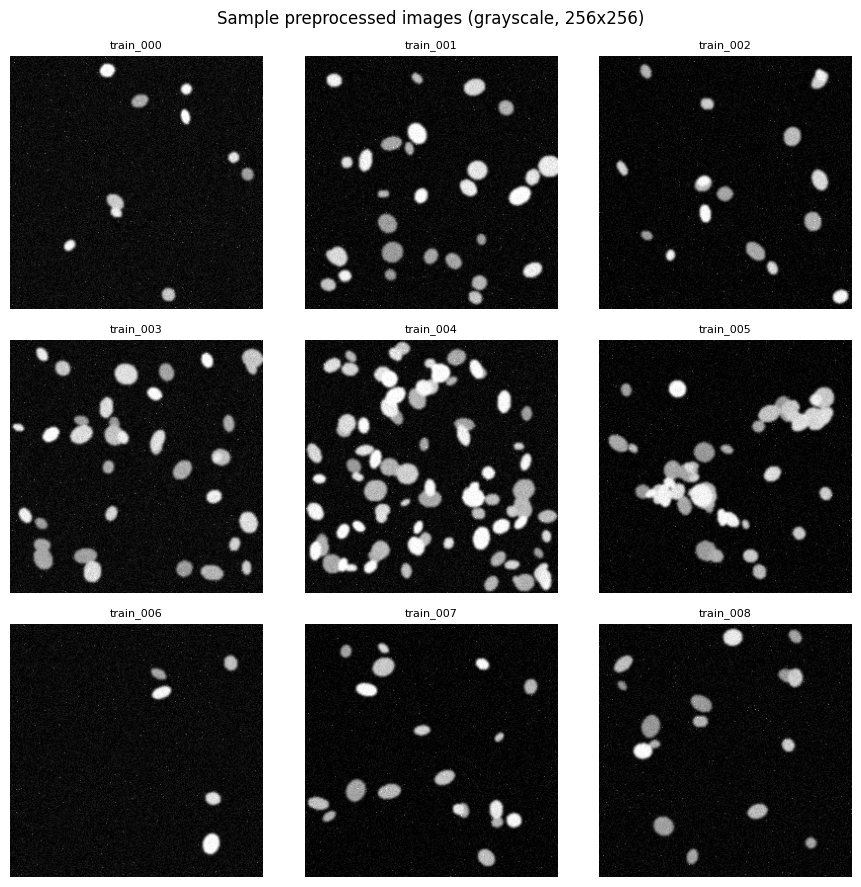

saved /content/nuclei_pipeline/outputs/figures/task1_sample_grid.png


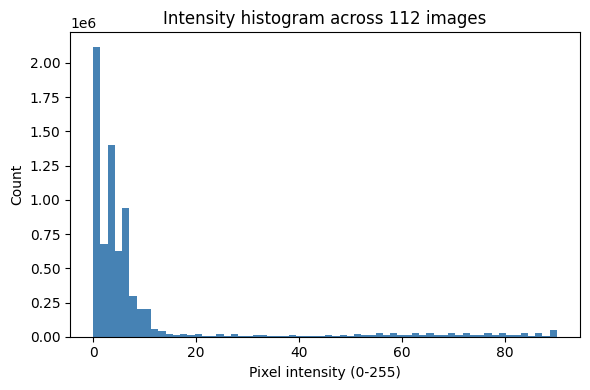

saved /content/nuclei_pipeline/outputs/figures/task1_intensity_histogram.png


In [11]:
def make_sample_grid(image_ids, n=9):
    n = min(n, len(image_ids))
    cols = 3
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.array(axes).reshape(-1)
    for i in range(rows * cols):
        axes[i].axis("off")
        if i < n:
            img = Image.open(os.path.join(PROC_IMG_DIR, image_ids[i] + ".png"))
            axes[i].imshow(img, cmap="gray")
            axes[i].set_title(image_ids[i], fontsize=8)
    fig.suptitle("Sample preprocessed images (grayscale, 256x256)")
    fig.tight_layout()
    path = os.path.join(FIG_DIR, "task1_sample_grid.png")
    fig.savefig(path, dpi=150)
    plt.show()
    print("saved", path)


def make_intensity_histogram(image_ids):
    # Pool every pixel from every image into one combined histogram.
    pixels = np.concatenate([np.array(Image.open(os.path.join(PROC_IMG_DIR, i + ".png")), dtype=np.uint8).ravel()
                              for i in image_ids])
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(pixels, bins=64, color="steelblue")
    ax.set_xlabel("Pixel intensity (0-255)"); ax.set_ylabel("Count")
    ax.set_title(f"Intensity histogram across {len(image_ids)} images")
    fig.tight_layout()
    path = os.path.join(FIG_DIR, "task1_intensity_histogram.png")
    fig.savefig(path, dpi=150)
    plt.show()
    print("saved", path)


make_sample_grid(all_ids, n=9)
make_intensity_histogram(all_ids)

### Multimodal LLM: naive vs optimised structured prompt

The structured prompt anchors the model as descriptive-not-diagnostic, forces a JSON schema
(`modality, tissue_type, notable_features, image_quality`), and explicitly permits `"uncertain"`.

In [12]:
def ollama_client():
    return ollama.Client(host=OLLAMA_HOST)


def describe_image(model, prompt, image_path, temperature=0.7):
    # temperature=0.7 (not greedy) is deliberate: we want to show real run-to-run variability below.
    c = ollama_client()
    resp = c.chat(model=model, messages=[{"role": "user", "content": prompt, "images": [image_path]}],
                  options={"temperature": temperature})
    return resp["message"]["content"]


def generate_text(model, prompt, temperature=0.3):
    c = ollama_client()
    resp = c.chat(model=model, messages=[{"role": "user", "content": prompt}], options={"temperature": temperature})
    return resp["message"]["content"]


def extract_json(text):
    # Small local models sometimes wrap JSON in prose or code fences -- try a few ways to pull it out
    # rather than crashing the pipeline on one malformed response.
    cleaned = re.sub(r"```(?:json)?", "", text).strip()
    try:
        return json.loads(cleaned), text
    except json.JSONDecodeError:
        pass
    match = re.search(r"\{.*\}", cleaned, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0)), text
        except json.JSONDecodeError:
            pass
    return None, text  # genuinely unparseable -- caller logs this rather than guessing


def generate_with_json_retry(model, prompt, retries=2, temperature=0.3):
    last_raw = ""
    for attempt in range(retries + 1):
        p = prompt if attempt == 0 else prompt + "\n\nReminder: reply with ONLY the JSON object, no extra text."
        raw = generate_text(model, p, temperature=temperature)
        last_raw = raw
        parsed, _ = extract_json(raw)
        if parsed is not None:
            return parsed, raw
        time.sleep(0.5)
    return None, last_raw

In [13]:
NAIVE_VLM_PROMPT = "Describe this medical image."

STRUCTURED_VLM_PROMPT = '''You are an assistant that writes DESCRIPTIVE, non-diagnostic summaries of
microscopy images for an educational image-analysis pipeline. You are not a
clinician and this is not a clinical report: do not name diseases, do not
give a diagnosis, and do not suggest treatment. Only describe what is
visually present.

If you are not confident about a property, write "uncertain" for that field
instead of guessing.

Look at the attached image and respond with ONLY a single JSON object, no
extra commentary, using exactly this schema:

{
  "modality": "<imaging modality, e.g. 'light microscopy of stained nuclei', or 'uncertain'>",
  "tissue_type": "<apparent tissue/cell type, or 'uncertain'>",
  "notable_features": "<1-3 sentences on visible structures: shape, density, clustering, staining, artifacts>",
  "image_quality": "<one of: good, moderate, poor, uncertain>"
}

Respond with the JSON object only.'''

print(NAIVE_VLM_PROMPT)
print()
print(STRUCTURED_VLM_PROMPT)

Describe this medical image.

You are an assistant that writes DESCRIPTIVE, non-diagnostic summaries of
microscopy images for an educational image-analysis pipeline. You are not a
clinician and this is not a clinical report: do not name diseases, do not
give a diagnosis, and do not suggest treatment. Only describe what is
visually present.

If you are not confident about a property, write "uncertain" for that field
instead of guessing.

Look at the attached image and respond with ONLY a single JSON object, no
extra commentary, using exactly this schema:

{
  "modality": "<imaging modality, e.g. 'light microscopy of stained nuclei', or 'uncertain'>",
  "tissue_type": "<apparent tissue/cell type, or 'uncertain'>",
  "notable_features": "<1-3 sentences on visible structures: shape, density, clustering, staining, artifacts>",
  "image_quality": "<one of: good, moderate, poor, uncertain>"
}

Respond with the JSON object only.


In [14]:
representative_id = split["val"][0] if split["val"] else all_ids[0]
img_path = os.path.join(PROC_IMG_DIR, representative_id + ".png")

# Naive prompt, single run.
naive_response = describe_image(VLM_MODEL, NAIVE_VLM_PROMPT, img_path, temperature=0.7)
print(" Naive response ")
print(naive_response)

 Naive response 
The image presents a medical scan of a patient's brain, specifically highlighting a small, dark-colored area. The purpose of this image is to provide a visual representation of the patient's brain structure and identify any potential abnormalities or areas of interest.

* A small, dark-colored area is visible in the brain scan:
	+ The area is located in the upper left corner of the image.
	+ It appears as a small, circular or oval-shaped region.
	+ The area is darker than the surrounding brain tissue, indicating a possible abnormality or anomaly.

The main finding from this image is the presence of a small, dark-colored area in the brain scan, which may indicate a potential issue or anomaly that requires further investigation. There are no significant changes or comparisons noted in this image.


In [15]:
# Structured prompt, repeated LLM_NUM_REPEATS times on the SAME image -- this is the evidence that
# repeated runs are not identical (temperature > 0 means the model samples differently each call).
structured_runs = []
for i in range(LLM_NUM_REPEATS):
    text = describe_image(VLM_MODEL, STRUCTURED_VLM_PROMPT, img_path, temperature=0.7)
    parsed, raw = extract_json(text)
    structured_runs.append({"run": i + 1, "parsed_json": parsed, "raw_response": raw})
    print(f"\nRun {i+1}:")
    print(json.dumps(parsed, indent=2) if parsed else "[parse failed] " + raw[:300])

task1_results = {"image_id": representative_id, "naive": {"prompt": NAIVE_VLM_PROMPT, "response": naive_response},
                  "structured_runs": structured_runs}
with open(os.path.join(JSON_DIR, "task1_vlm_outputs.json"), "w") as f:
    json.dump(task1_results, f, indent=2)


Run 1:
{
  "modality": "uncertain",
  "tissue_type": "uncertain",
  "notable_features": "The image appears to be a dark background with several light spots, but there is no clear indication of what these spots are or what they represent.",
  "image_quality": "poor"
}

Run 2:
{
  "modality": "uncertain",
  "tissue_type": "uncertain",
  "notable_features": "The image is extremely blurry and the features are indistinguishable.",
  "image_quality": "poor"
}

Run 3:
{
  "modality": "uncertain",
  "tissue_type": "uncertain",
  "notable_features": "The image appears to be a low-resolution, pixelated representation of a cell or tissue sample, but the details are indistinct.",
  "image_quality": "poor"
}


## Task 2 — Classical features & numbers-first LLM interpretation

Otsu thresholding + morphological cleanup + `regionprops_table`, converted to a numbers-only summary
sent to **phi3** (it never sees the image), compared against Task 1's direct VLM output.

In [16]:
REGION_PROPERTIES = ["label", "area", "eccentricity", "solidity", "mean_intensity", "perimeter", "centroid"]


def otsu_segment(gray_float):
    thresh = threshold_otsu(gray_float)
    binary = gray_float > thresh
    # Otsu doesn't know which side of the threshold is "foreground". Nuclei are usually a minority
    # of the image's pixels, so if more than half the pixels are "on" we assume the mask is inverted.
    if binary.mean() > 0.5:
        binary = ~binary
    binary = morphology.remove_small_objects(binary, min_size=15)  # drop thresholding noise/specks
    binary = morphology.binary_opening(binary, morphology.disk(1))  # trim thin protrusions
    binary = morphology.binary_closing(binary, morphology.disk(2))  # fill small holes
    return binary


def region_feature_table(binary_mask, intensity_float):
    labeled = measure.label(binary_mask)
    if labeled.max() == 0:
        return labeled, pd.DataFrame(columns=REGION_PROPERTIES)
    table = measure.regionprops_table(labeled, intensity_image=intensity_float, properties=REGION_PROPERTIES)
    return labeled, pd.DataFrame(table)


def summarize_features(df):
    if df.empty:
        return "No connected components were detected above the size threshold."
    return "\n".join([
        f"Number of detected objects: {len(df)}",
        f"Mean area (pixels): {df['area'].mean():.1f} (std {df['area'].std():.1f}, min {df['area'].min():.0f}, max {df['area'].max():.0f})",
        f"Mean eccentricity: {df['eccentricity'].mean():.3f} (0 = circle, closer to 1 = elongated)",
        f"Mean solidity: {df['solidity'].mean():.3f} (fraction of convex hull filled; lower = irregular shape)",
        f"Mean object intensity (0-1 scale): {df['mean_intensity'].mean():.3f}",
        f"Mean perimeter (pixels): {df['perimeter'].mean():.1f}",
    ])

In [17]:
CLASSICAL_SUMMARY_PROMPT_TEMPLATE = '''You are an assistant that writes descriptive, non-diagnostic summaries of
microscopy images for an educational pipeline. You have NOT seen the image
itself -- you are only given quantitative measurements extracted by
classical image processing (Otsu thresholding + connected-component
analysis). Do not invent visual details that are not implied by the
numbers. If a judgement is not well supported by the numbers, say
"uncertain" rather than guessing.

Measurements for this image:
{summary_text}

Write:
1. One paragraph (3-5 sentences) describing what these measurements suggest
   about the image, in plain language.
2. Then, on a new line, ONLY a JSON object with exactly this schema:

{{
  "n_objects": <integer>,
  "density_class": "<one of: sparse, moderate, dense, uncertain>",
  "shape_regularity": "<one of: regular, irregular, mixed, uncertain>",
  "quality_flag": "<one of: good, moderate, poor, uncertain>"
}}
'''
print(CLASSICAL_SUMMARY_PROMPT_TEMPLATE)

You are an assistant that writes descriptive, non-diagnostic summaries of
microscopy images for an educational pipeline. You have NOT seen the image
itself -- you are only given quantitative measurements extracted by
classical image processing (Otsu thresholding + connected-component
analysis). Do not invent visual details that are not implied by the
numbers. If a judgement is not well supported by the numbers, say
"uncertain" rather than guessing.

Measurements for this image:
{summary_text}

Write:
1. One paragraph (3-5 sentences) describing what these measurements suggest
   about the image, in plain language.
2. Then, on a new line, ONLY a JSON object with exactly this schema:

{{
  "n_objects": <integer>,
  "density_class": "<one of: sparse, moderate, dense, uncertain>",
  "shape_regularity": "<one of: regular, irregular, mixed, uncertain>",
  "quality_flag": "<one of: good, moderate, poor, uncertain>"
}}



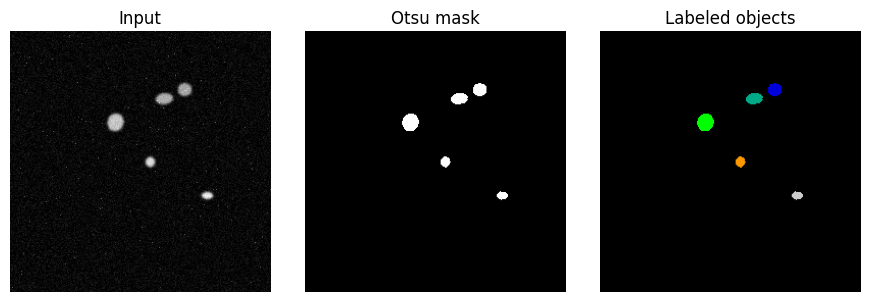

Number of detected objects: 5
Mean area (pixels): 131.4 (std 64.4, min 67, max 227)
Mean eccentricity: 0.519 (0 = circle, closer to 1 = elongated)
Mean solidity: 0.955 (fraction of convex hull filled; lower = irregular shape)
Mean object intensity (0-1 scale): 0.224
Mean perimeter (pixels): 39.7


In [18]:
img = Image.open(os.path.join(PROC_IMG_DIR, representative_id + ".png")).convert("L")
arr = np.array(img, dtype=np.float32) / 255.0

otsu_mask = otsu_segment(arr)
labeled, feat_df = region_feature_table(otsu_mask, arr)
summary_text = summarize_features(feat_df)
feat_df.to_csv(os.path.join(CSV_DIR, f"task2_features_{representative_id}.csv"), index=False)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(arr, cmap="gray"); axes[0].set_title("Input"); axes[0].axis("off")
axes[1].imshow(otsu_mask, cmap="gray"); axes[1].set_title("Otsu mask"); axes[1].axis("off")
axes[2].imshow(labeled, cmap="nipy_spectral"); axes[2].set_title("Labeled objects"); axes[2].axis("off")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, f"task2_otsu_panel_{representative_id}.png"), dpi=150)
plt.show()

print(summary_text)

In [19]:
task2_prompt = CLASSICAL_SUMMARY_PROMPT_TEMPLATE.format(summary_text=summary_text)
task2_parsed, task2_raw = generate_with_json_retry(TEXT_MODEL, task2_prompt)

print("--- phi3 response ---")
print(task2_raw)
print()
print("--- Parsed JSON ---")
print(json.dumps(task2_parsed, indent=2))

with open(os.path.join(JSON_DIR, "task2_classical_llm_output.json"), "w") as f:
    json.dump({"image_id": representative_id, "summary_text": summary_text, "prompt": task2_prompt,
               "llm_raw_response": task2_raw, "llm_parsed_json": task2_parsed}, f, indent=2)

# Direct comparison: Task 1 (VLM) vs Task 2 (numbers-first), same image.
comparison = {"image_id": representative_id,
              "task1_vlm_structured": structured_runs[0]["parsed_json"],
              "task2_numbers_first": task2_parsed}
print("\n--- Task 1 vs Task 2 comparison ---")
print(json.dumps(comparison, indent=2))
with open(os.path.join(JSON_DIR, "task1_vs_task2_comparison.json"), "w") as f:
    json.dump(comparison, f, indent=2)

--- phi3 response ---
1. The measurements suggest that the image contains five distinct objects with varying sizes and shapes but similar overall appearance in terms of their circularity (mean eccentricity close to zero). These objects appear quite solid as indicated by high mean solidity values nearing one, suggesting they are mostly filled within their convex hulls without much empty space inside. The average object size is moderate with a standard deviation that indicates some variability in the sizes of these objects; however, all fall close to an area around 130 pixels squared. Object intensities vary but on average appear dimmer than mid-tones as their mean intensity value hovers nearer to dark tones (22%). The perimeter measurements suggest that while there is some variation in the contour lengths of these objects, they are not exceedingly long or short when compared with one another.

```json
{
  "n_objects": 5,
  "density_class": "moderate",
  "shape_regularity": "mixed",
  "q

## Task 3 — U-Net segmentation

A small U-Net (encoder/decoder with skip connections), trained on the train split, evaluated with mean
Dice and IoU on the held-out val split, with loss/Dice curves and side-by-side prediction panels.

In [20]:
class NucleiDataset(Dataset):
    def __init__(self, image_ids, augment=False):
        self.ids = image_ids
        self.augment = augment  # only True for the training split

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        image_id = self.ids[idx]
        img = Image.open(os.path.join(PROC_IMG_DIR, image_id + ".png")).convert("L")
        mask = Image.open(os.path.join(PROC_MASK_DIR, image_id + ".png")).convert("L")
        img_arr = np.array(img, dtype=np.float32) / 255.0
        mask_arr = (np.array(mask, dtype=np.float32) > 127).astype(np.float32)
        if self.augment and random.random() < 0.5:  # random flip augmentation, applied to both image and mask
            img_arr, mask_arr = np.fliplr(img_arr).copy(), np.fliplr(mask_arr).copy()
        if self.augment and random.random() < 0.5:
            img_arr, mask_arr = np.flipud(img_arr).copy(), np.flipud(mask_arr).copy()
        return torch.from_numpy(img_arr).unsqueeze(0), torch.from_numpy(mask_arr).unsqueeze(0), image_id


def get_device():
    if torch.cuda.is_available(): return torch.device("cuda")
    if torch.backends.mps.is_available(): return torch.device("mps")
    return torch.device("cpu")


device = get_device()
print("Using device:", device)

Using device: cuda


In [21]:
def double_conv(in_ch, out_ch):
    # The basic U-Net block: two 3x3 convs, each with batchnorm + ReLU.
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
    )


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_channels=16):
        super().__init__()
        c = base_channels
        # Encoder: 4 stages, halving resolution / doubling channels each time.
        self.enc1, self.enc2, self.enc3, self.enc4 = double_conv(in_channels, c), double_conv(c, c*2), double_conv(c*2, c*4), double_conv(c*4, c*8)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = double_conv(c*8, c*16)
        # Decoder: upsample + concatenate matching encoder skip connection + fuse.
        self.up4, self.dec4 = nn.ConvTranspose2d(c*16, c*8, 2, stride=2), double_conv(c*16, c*8)
        self.up3, self.dec3 = nn.ConvTranspose2d(c*8, c*4, 2, stride=2), double_conv(c*8, c*4)
        self.up2, self.dec2 = nn.ConvTranspose2d(c*4, c*2, 2, stride=2), double_conv(c*4, c*2)
        self.up1, self.dec1 = nn.ConvTranspose2d(c*2, c, 2, stride=2), double_conv(c*2, c)
        self.out_conv = nn.Conv2d(c, out_channels, 1)  # 1x1 conv -> single-channel logits

    def forward(self, x):
        e1 = self.enc1(x); e2 = self.enc2(self.pool(e1)); e3 = self.enc3(self.pool(e2)); e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)  # raw logits, sigmoid applied outside


def dice_coefficient(pred_probs, target, eps=1e-6):
    # Soft Dice = 2*|A n B| / (|A|+|B|), averaged over the batch.
    p, t = pred_probs.reshape(pred_probs.shape[0], -1), target.reshape(target.shape[0], -1)
    inter = (p * t).sum(dim=1)
    return ((2 * inter + eps) / (p.sum(dim=1) + t.sum(dim=1) + eps)).mean()


def iou_score(pred_probs, target, eps=1e-6):
    # IoU on the thresholded (hard) prediction, averaged over the batch.
    pb = (pred_probs > 0.5).float()
    p, t = pb.reshape(pb.shape[0], -1), target.reshape(target.shape[0], -1)
    inter = (p * t).sum(dim=1)
    union = ((p + t) > 0).float().sum(dim=1)
    return ((inter + eps) / (union + eps)).mean()


class DiceLoss(nn.Module):
    def forward(self, logits, target):
        return 1 - dice_coefficient(torch.sigmoid(logits), target)


class BCEDiceLoss(nn.Module):
    # BCE gives a strong early gradient signal; Dice directly optimises the overlap metric we evaluate on.
    def __init__(self):
        super().__init__()
        self.bce, self.dice = nn.BCEWithLogitsLoss(), DiceLoss()

    def forward(self, logits, target):
        return self.bce(logits, target) + self.dice(logits, target)


def get_loss(loss_type):
    return {"bce": nn.BCEWithLogitsLoss(), "dice": DiceLoss(), "bce_dice": BCEDiceLoss()}[loss_type]

def dice_coefficient_hard(pred_probs, target, eps=1e-6):
    # Thresholded (hard) Dice -- directly comparable to iou_score, which is also computed
    # on the thresholded mask. The original dice_coefficient() stays soft/continuous on
    # purpose, since DiceLoss needs it to be differentiable for training; this version is
    # only for reporting evaluation metrics, so Dice and IoU are measuring the same thing.
    pred_bin = (pred_probs > 0.5).float()
    p, t = pred_bin.reshape(pred_bin.shape[0], -1), target.reshape(target.shape[0], -1)
    inter = (p * t).sum(dim=1)
    return ((2 * inter + eps) / (p.sum(dim=1) + t.sum(dim=1) + eps)).mean()


In [22]:
train_ds = NucleiDataset(split["train"], augment=True)
val_ds = NucleiDataset(split["val"], augment=False)
train_loader = DataLoader(train_ds, batch_size=UNET_BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=UNET_BATCH_SIZE, shuffle=False)

model = UNet(in_channels=1, out_channels=1, base_channels=UNET_BASE_CHANNELS).to(device)
criterion = get_loss(LOSS_TYPE)
optimizer = torch.optim.Adam(model.parameters(), lr=UNET_LR)

history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}
best_dice, best_ckpt_path = -1.0, os.path.join(CKPT_DIR, "unet_best.pt")

for epoch in range(1, UNET_EPOCHS + 1):
    # train
    model.train()
    running_loss = 0.0
    for imgs, masks, _ in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / len(train_ds)

    # validate
    model.eval()
    val_loss = val_dice = val_iou = 0.0
    n = 0
    with torch.no_grad():
        for imgs, masks, _ in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            loss = criterion(logits, masks)
            probs = torch.sigmoid(logits)
            val_loss += loss.item() * imgs.size(0)
            val_dice += dice_coefficient_hard(probs, masks).item() * imgs.size(0)
            val_iou += iou_score(probs, masks).item() * imgs.size(0)
            n += imgs.size(0)
    val_loss, val_dice, val_iou = val_loss / n, val_dice / n, val_iou / n

    history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice); history["val_iou"].append(val_iou)
    print(f"[epoch {epoch:02d}/{UNET_EPOCHS}] train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_dice={val_dice:.4f} val_iou={val_iou:.4f}")

    if val_dice > best_dice:  # keep only the best-validation-Dice checkpoint, not the last epoch
        best_dice = val_dice
        torch.save(model.state_dict(), best_ckpt_path)

with open(os.path.join(JSON_DIR, "task3_history.json"), "w") as f:
    json.dump(history, f, indent=2)

[epoch 01/25] train_loss=1.2878 val_loss=1.5839 val_dice=0.1373 val_iou=0.0757
[epoch 02/25] train_loss=1.0809 val_loss=1.3248 val_dice=0.0628 val_iou=0.0326
[epoch 03/25] train_loss=1.0221 val_loss=1.1619 val_dice=0.7403 val_iou=0.5939
[epoch 04/25] train_loss=0.9759 val_loss=1.0172 val_dice=0.9369 val_iou=0.8814
[epoch 05/25] train_loss=0.9343 val_loss=0.9794 val_dice=0.9724 val_iou=0.9463
[epoch 06/25] train_loss=0.8924 val_loss=0.8878 val_dice=0.9596 val_iou=0.9226
[epoch 07/25] train_loss=0.8522 val_loss=0.8685 val_dice=0.9688 val_iou=0.9396
[epoch 08/25] train_loss=0.8133 val_loss=0.8091 val_dice=0.9675 val_iou=0.9371
[epoch 09/25] train_loss=0.7751 val_loss=0.7984 val_dice=0.9848 val_iou=0.9702
[epoch 10/25] train_loss=0.7382 val_loss=0.7409 val_dice=0.9878 val_iou=0.9760
[epoch 11/25] train_loss=0.7003 val_loss=0.7055 val_dice=0.9906 val_iou=0.9813
[epoch 12/25] train_loss=0.6652 val_loss=0.6732 val_dice=0.9846 val_iou=0.9697
[epoch 13/25] train_loss=0.6295 val_loss=0.6314 val_

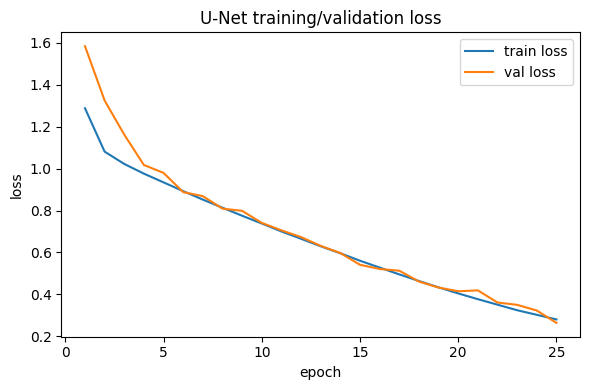

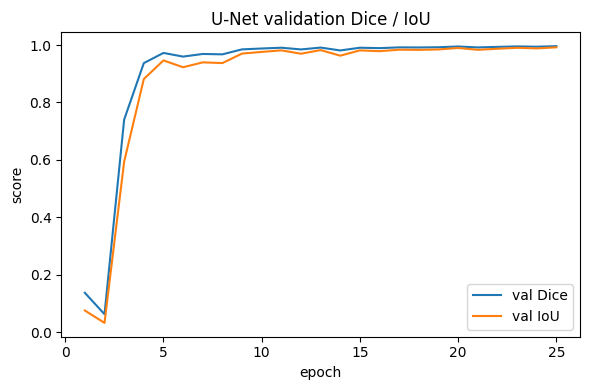

In [23]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(epochs_range, history["train_loss"], label="train loss")
ax.plot(epochs_range, history["val_loss"], label="val loss")
ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.legend(); ax.set_title("U-Net training/validation loss")
fig.tight_layout(); fig.savefig(os.path.join(FIG_DIR, "task3_loss_curve.png"), dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(epochs_range, history["val_dice"], label="val Dice")
ax.plot(epochs_range, history["val_iou"], label="val IoU")
ax.set_xlabel("epoch"); ax.set_ylabel("score"); ax.legend(); ax.set_title("U-Net validation Dice / IoU")
fig.tight_layout(); fig.savefig(os.path.join(FIG_DIR, "task3_dice_iou_curve.png"), dpi=150); plt.show()

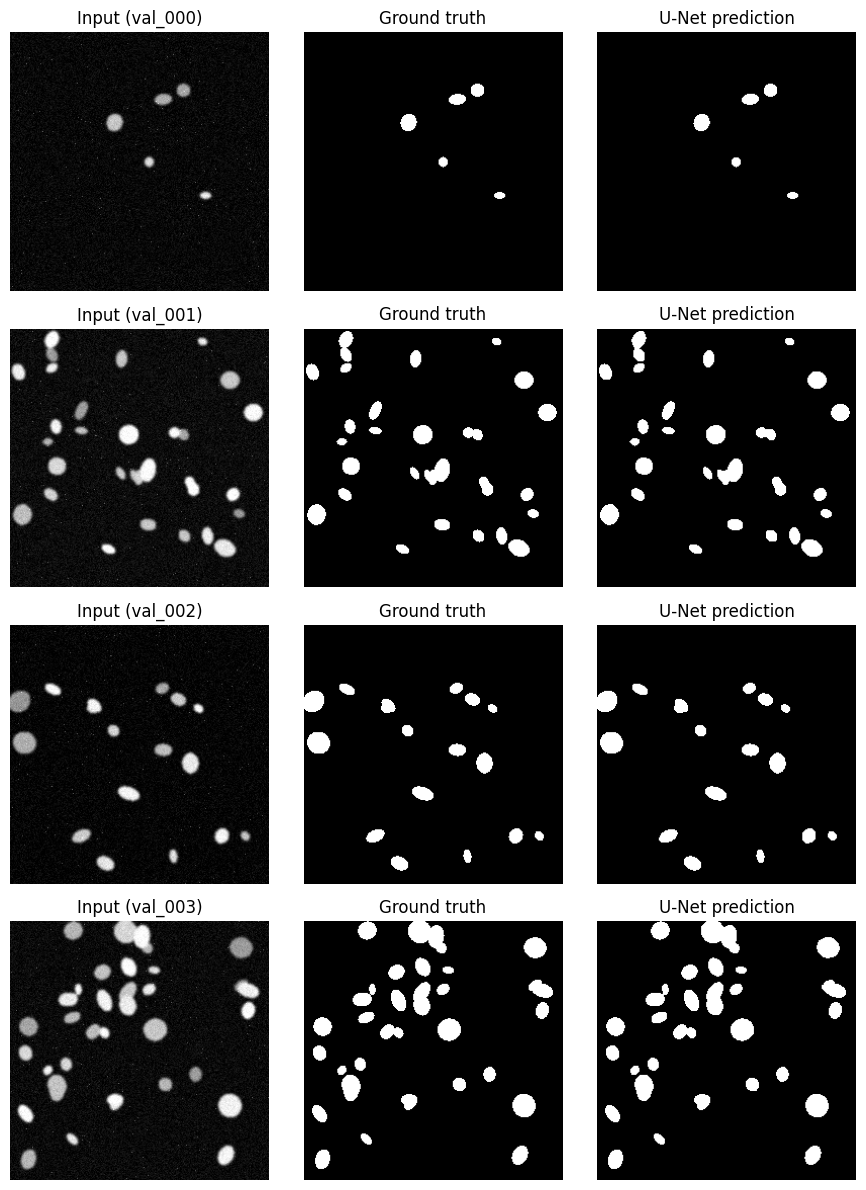

{
  "loss_type": "bce_dice",
  "epochs": 25,
  "best_val_dice": 0.9959512233734131,
  "final_val_dice": 0.9959512233734131,
  "final_val_iou": 0.9919380426406861,
  "checkpoint": "/content/nuclei_pipeline/outputs/checkpoints/unet_best.pt"
}


In [24]:
# Reload the BEST checkpoint (highest val Dice across all epochs) before visualising/reporting.
model.load_state_dict(torch.load(best_ckpt_path, map_location=device))
model.to(device)

n_panels = min(NUM_VAL_PANELS, len(val_ds))
fig, axes = plt.subplots(n_panels, 3, figsize=(9, 3 * n_panels))
if n_panels == 1:
    axes = axes.reshape(1, 3)

model.eval()
with torch.no_grad():
    for i in range(n_panels):
        img_t, mask_t, image_id = val_ds[i]
        pred = torch.sigmoid(model(img_t.unsqueeze(0).to(device)))[0, 0].cpu().numpy()
        pred_bin = (pred > 0.5).astype(np.float32)
        axes[i, 0].imshow(img_t[0].numpy(), cmap="gray"); axes[i, 0].set_title(f"Input ({image_id})"); axes[i, 0].axis("off")
        axes[i, 1].imshow(mask_t[0].numpy(), cmap="gray"); axes[i, 1].set_title("Ground truth"); axes[i, 1].axis("off")
        axes[i, 2].imshow(pred_bin, cmap="gray"); axes[i, 2].set_title("U-Net prediction"); axes[i, 2].axis("off")

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "task3_val_panels.png"), dpi=150)
plt.show()

task3_metrics = {"loss_type": LOSS_TYPE, "epochs": UNET_EPOCHS, "best_val_dice": best_dice,
                  "final_val_dice": history["val_dice"][-1], "final_val_iou": history["val_iou"][-1],
                  "checkpoint": best_ckpt_path}
print(json.dumps(task3_metrics, indent=2))
with open(os.path.join(JSON_DIR, "task3_metrics.json"), "w") as f:
    json.dump(task3_metrics, f, indent=2)

## Task 4 — Hybrid pipeline on unseen test images

For every image in the **test** split (never used in U-Net training/validation):
U-Net mask -> regionprops feature table -> phi3 structured JSON -> narrative.
All records are aggregated into a DataFrame and saved as CSV.

In [25]:
HYBRID_PROMPT_TEMPLATE = '''You are an assistant that writes descriptive, non-diagnostic summaries of
microscopy images for an educational pipeline. You have NOT seen the image.
You are only given quantitative measurements computed from a U-Net
segmentation mask via connected-component analysis. Do not invent details
the numbers do not support. Use "uncertain" where appropriate.

Image ID: {image_id}
Measurements:
{summary_text}

Write:
1. One short paragraph (2-4 sentences) narrating what the measurements
   suggest.
2. Then, on a new line, ONLY a JSON object with exactly this schema:

{{
  "image_id": "{image_id}",
  "n_objects": <integer>,
  "mean_area": <number>,
  "density_class": "<one of: sparse, moderate, dense, uncertain>",
  "quality_flag": "<one of: good, moderate, poor, uncertain>"
}}
'''
print(HYBRID_PROMPT_TEMPLATE)

You are an assistant that writes descriptive, non-diagnostic summaries of
microscopy images for an educational pipeline. You have NOT seen the image.
You are only given quantitative measurements computed from a U-Net
segmentation mask via connected-component analysis. Do not invent details
the numbers do not support. Use "uncertain" where appropriate.

Image ID: {image_id}
Measurements:
{summary_text}

Write:
1. One short paragraph (2-4 sentences) narrating what the measurements
   suggest.
2. Then, on a new line, ONLY a JSON object with exactly this schema:

{{
  "image_id": "{image_id}",
  "n_objects": <integer>,
  "mean_area": <number>,
  "density_class": "<one of: sparse, moderate, dense, uncertain>",
  "quality_flag": "<one of: good, moderate, poor, uncertain>"
}}



In [26]:
def run_unet_on_image(image_id):
    img = Image.open(os.path.join(PROC_IMG_DIR, image_id + ".png")).convert("L")
    arr = np.array(img, dtype=np.float32) / 255.0
    t = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0).to(device)  # (H,W) -> (1,1,H,W)
    with torch.no_grad():
        probs = torch.sigmoid(model(t))[0, 0].cpu().numpy()
    return arr, probs > 0.5


test_ids = split["test"]
print(f"Running hybrid pipeline on {len(test_ids)} unseen test images")

records = []
for image_id in test_ids:
    arr, mask = run_unet_on_image(image_id)
    _, df = region_feature_table(mask, arr)
    summary_text = summarize_features(df)

    prompt = HYBRID_PROMPT_TEMPLATE.format(image_id=image_id, summary_text=summary_text)
    parsed, raw = generate_with_json_retry(TEXT_MODEL, prompt)

    record = {
        "image_id": image_id,
        "n_objects": int(len(df)),
        "mean_area": float(df["area"].mean()) if len(df) else 0.0,
        "density_class": parsed.get("density_class") if parsed else "uncertain",
        "quality_flag": parsed.get("quality_flag") if parsed else "uncertain",
        "narrative_raw": raw,
        "llm_parsed_json": parsed,
    }
    records.append(record)
    print(f"{image_id}: n_objects={record['n_objects']} density={record['density_class']} quality={record['quality_flag']}")

with open(os.path.join(JSON_DIR, "task4_hybrid_records.json"), "w") as f:
    json.dump(records, f, indent=2)

Running hybrid pipeline on 12 unseen test images
test_000: n_objects=8 density=uncertain quality=good
test_001: n_objects=14 density=moderate quality=good
test_002: n_objects=26 density=moderate quality=good
test_003: n_objects=19 density=moderate quality=good
test_004: n_objects=43 density=moderate quality=good
test_005: n_objects=16 density=sparse quality=moderate
test_006: n_objects=8 density=moderate quality=good
test_007: n_objects=23 density=moderate quality=good
test_008: n_objects=23 density=moderate quality=good
test_009: n_objects=21 density=moderate quality=good
test_010: n_objects=37 density=moderate quality=good
test_011: n_objects=20 density=moderate quality=good


In [27]:
hybrid_df = pd.DataFrame([{"image_id": r["image_id"], "n_objects": r["n_objects"], "mean_area": r["mean_area"],
                            "density_class": r["density_class"], "quality_flag": r["quality_flag"]} for r in records])
hybrid_df.to_csv(os.path.join(CSV_DIR, "task4_hybrid_pipeline_results.csv"), index=False)
hybrid_df

,image_id,n_objects,mean_area,density_class,quality_flag
0,test_000,8,191.875000,uncertain,good
1,test_001,14,201.071429,moderate,good
2,test_002,26,219.423077,moderate,good
3,test_003,19,204.210526,moderate,good
4,test_004,43,328.697674,moderate,good
5,test_005,16,406.812500,sparse,moderate
6,test_006,8,198.500000,moderate,good
7,test_007,23,205.869565,moderate,good
8,test_008,23,240.086957,moderate,good
9,test_009,21,179.238095,moderate,good


In [28]:
# Example narrative + JSON for the report.
if records:
    print("Example (image:", records[0]["image_id"], ")")
    print(records[0]["narrative_raw"])

Example (image: test_000 )
The measurements from the U-Net segmentation mask for image ID test_000 suggest that there are eight distinct objects with a mean area indicating they vary in size but tend to be smaller on average. The relatively low eccentricity points towards these shapes being more circular, while their high solidity implies well-defined and less irregular forms. Objects have moderate intensity levels within the image suggesting some contrast between them and the background or other objects. Their perimeters are not very large relative to area sizes which might indicate a certain level of complexity in object boundaries but still maintaining good overall shape quality due to high solidity values.

```json
{
  "image_id": "test_000",
  "n_objects": 8,
  "mean_area": 191.9,
  "density_class": "uncertain",
  "quality_flag": "good"
}
```


## Extension (extra credit) — Robustness

Corrupt one test image with heavy Gaussian blur and trace the effect through the Otsu mask, the U-Net
mask, the feature table, and the LLM narrative -- to find the earliest stage the corruption becomes
clearly detectable.

Corruption source: synthetic gaussian_blur_sigma_4.0 (test_corrupted/ not found)


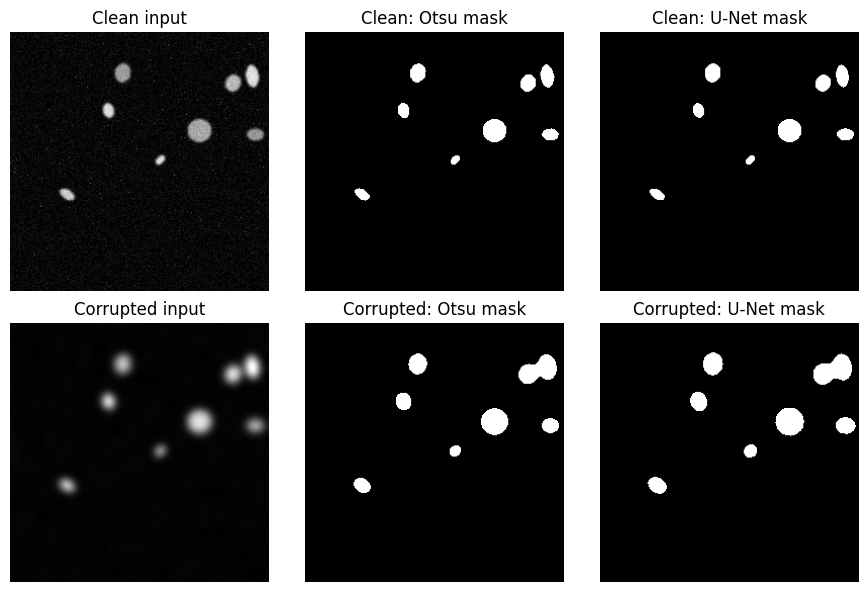

In [29]:
def run_pipeline_on_array(arr):
    otsu_mask = otsu_segment(arr)
    _, otsu_df = region_feature_table(otsu_mask, arr)
    t = torch.from_numpy(arr.astype(np.float32)).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.sigmoid(model(t))[0, 0].cpu().numpy()
    unet_mask = probs > 0.5
    _, unet_df = region_feature_table(unet_mask, arr)
    return {"otsu_mask": otsu_mask, "otsu_df": otsu_df, "unet_mask": unet_mask, "unet_df": unet_df}


ext_test_ids = split["test"] or split["val"]
ext_image_id = ext_test_ids[0]

ext_img = Image.open(os.path.join(PROC_IMG_DIR, ext_image_id + ".png")).convert("L")
clean = np.array(ext_img, dtype=np.float32) / 255.0

# Prefer the dataset's OWN corrupted test image (data/raw/.../test_corrupted/images/<id>.png) over a
# synthetic blur -- it's a more realistic, dataset-author-designed corruption than anything we'd
# invent ourselves. Fall back to a manual Gaussian blur only if that folder isn't present.
corrupted_path = os.path.join(DATASET_ROOT, "test_corrupted", "images", ext_image_id + ".png")
if os.path.exists(corrupted_path):
    corrupted_img = Image.open(corrupted_path).convert("L").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    corrupted = np.array(corrupted_img, dtype=np.float32) / 255.0
    corruption_label = "dataset-provided test_corrupted image"
else:
    corrupted = gaussian_filter(clean, sigma=4.0)  # heavy blur -- simulates a severe focus artefact
    corruption_label = "synthetic gaussian_blur_sigma_4.0 (test_corrupted/ not found)"

print("Corruption source:", corruption_label)

clean_res, corrupt_res = run_pipeline_on_array(clean), run_pipeline_on_array(corrupted)

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
axes[0,0].imshow(clean, cmap="gray"); axes[0,0].set_title("Clean input"); axes[0,0].axis("off")
axes[0,1].imshow(clean_res["otsu_mask"], cmap="gray"); axes[0,1].set_title("Clean: Otsu mask"); axes[0,1].axis("off")
axes[0,2].imshow(clean_res["unet_mask"], cmap="gray"); axes[0,2].set_title("Clean: U-Net mask"); axes[0,2].axis("off")
axes[1,0].imshow(corrupted, cmap="gray"); axes[1,0].set_title("Corrupted input"); axes[1,0].axis("off")
axes[1,1].imshow(corrupt_res["otsu_mask"], cmap="gray"); axes[1,1].set_title("Corrupted: Otsu mask"); axes[1,1].axis("off")
axes[1,2].imshow(corrupt_res["unet_mask"], cmap="gray"); axes[1,2].set_title("Corrupted: U-Net mask"); axes[1,2].axis("off")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "extension_robustness_panel.png"), dpi=150)
plt.show()

In [30]:
corrupt_summary = summarize_features(corrupt_res["unet_df"])
ext_prompt = HYBRID_PROMPT_TEMPLATE.format(image_id=ext_image_id + "_corrupted", summary_text=corrupt_summary)
ext_parsed, ext_raw = generate_with_json_retry(TEXT_MODEL, ext_prompt)

robustness_report = {
    "image_id": ext_image_id,
    "corruption": corruption_label,
    "clean": {"otsu_n_objects": int(len(clean_res["otsu_df"])), "unet_n_objects": int(len(clean_res["unet_df"]))},
    "corrupted": {"otsu_n_objects": int(len(corrupt_res["otsu_df"])), "unet_n_objects": int(len(corrupt_res["unet_df"])),
                  "unet_summary_text": corrupt_summary, "llm_parsed_json": ext_parsed, "llm_raw_response": ext_raw},
}
print(json.dumps(robustness_report, indent=2))
with open(os.path.join(JSON_DIR, "extension_robustness_report.json"), "w") as f:
    json.dump(robustness_report, f, indent=2)

{
  "image_id": "test_000",
  "corruption": "synthetic gaussian_blur_sigma_4.0 (test_corrupted/ not found)",
  "clean": {
    "otsu_n_objects": 8,
    "unet_n_objects": 8
  },
  "corrupted": {
    "otsu_n_objects": 7,
    "unet_n_objects": 7,
    "unet_summary_text": "Number of detected objects: 7\nMean area (pixels): 370.9 (std 228.0, min 135, max 759)\nMean eccentricity: 0.520 (0 = circle, closer to 1 = elongated)\nMean solidity: 0.953 (fraction of convex hull filled; lower = irregular shape)\nMean object intensity (0-1 scale): 0.118\nMean perimeter (pixels): 69.0",
    "llm_parsed_json": {
      "image_id": "test_000_corrupted",
      "n_objects": 7,
      "mean_area": 370.9,
      "density_class": "moderate",
      "quality_flag": "uncertain"
    },
    "llm_raw_response": "The measurements suggest that there are seven objects detected in the image with a mean area suggesting they vary from relatively small to larger entities. The average eccentricity indicates these shapes tend to

## Output index (for the report)

- EDA: `outputs/figures/task1_sample_grid.png`, `task1_intensity_histogram.png`
- Task 1 VLM: `outputs/json/task1_vlm_outputs.json`
- Task 2: `outputs/figures/task2_otsu_panel_*.png`, `outputs/json/task2_classical_llm_output.json`, `task1_vs_task2_comparison.json`
- Task 3: `outputs/figures/task3_loss_curve.png`, `task3_dice_iou_curve.png`, `task3_val_panels.png`, `outputs/json/task3_metrics.json`
- Task 4: `outputs/json/task4_hybrid_records.json`, `outputs/csv/task4_hybrid_pipeline_results.csv`
- Extension: `outputs/figures/extension_robustness_panel.png`, `outputs/json/extension_robustness_report.json`

## Download your results before the session ends

Colab wipes `/content/` when the runtime disconnects or resets. Run this cell before you close the tab
so you have everything (figures, JSON records, CSVs, and the trained U-Net checkpoint) safely on your
own computer for the report.

In [31]:
import shutil
from google.colab import files

zip_path = "/content/nuclei_pipeline_outputs.zip"
shutil.make_archive("/content/nuclei_pipeline_outputs", "zip", OUT_DIR)
print("Zipped outputs to", zip_path)

files.download(zip_path)

Zipped outputs to /content/nuclei_pipeline_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>